In [13]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import math

In [14]:
# Read file
file_path = "Data.xlsx"
geom_df = pd.read_excel(file_path, sheet_name="Geometry")
conn_df = pd.read_excel(file_path, sheet_name="Members")

# Read file
file_path = "Data.xlsx"
geom_df = pd.read_excel(file_path, sheet_name="Geometry")
conn_df = pd.read_excel(file_path, sheet_name="Members")



# Read 3D nodes
node_df = geom_df[
    geom_df["Nodes"].notna() &
    geom_df["X"].notna() &
    geom_df["Y"].notna() &
    geom_df["Z"].notna()
].copy()

nodes_3d = {
    int(row["Nodes"]): (float(row["X"]), float(row["Y"]), float(row["Z"]))
    for _, row in node_df.iterrows()
}


# Read members
elem_df = conn_df[conn_df["Members"].notna()].copy()
elements = []

def parse_nodes_connected(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    m = re.fullmatch(r"\s*(\d+)\s*-\s*(\d+)\s*", s)
    if not m:
        return None
    return int(m.group(1)), int(m.group(2))

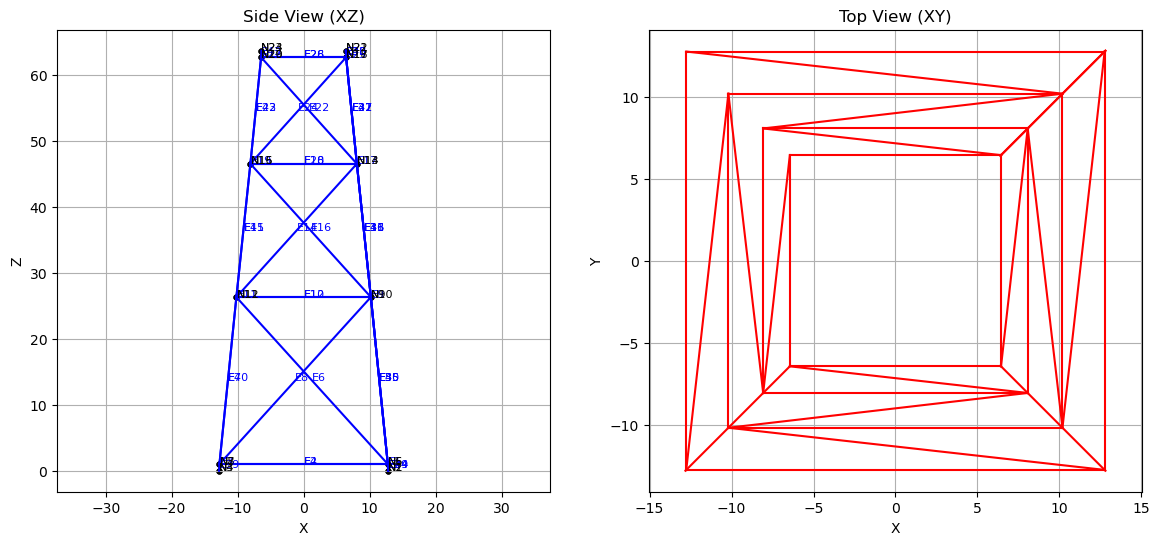

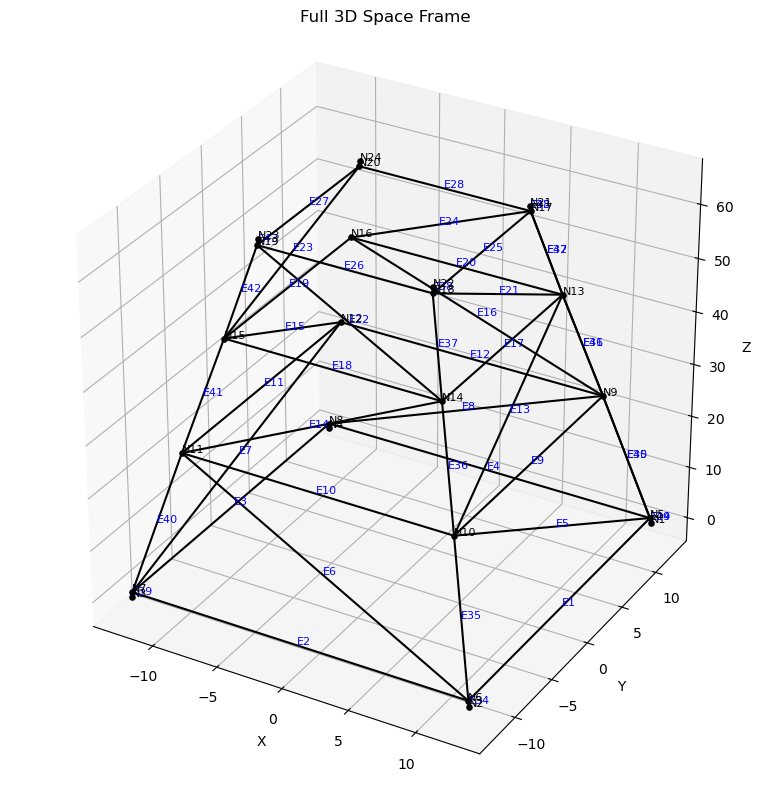

    Number Element type     L_m  L_eff_m  Chosen diameter (inches)  \
0        1            H  25.530   25.530                      24.0   
1        2            H  25.530   25.530                      24.0   
2        3            H  25.530   25.530                      24.0   
3        4            H  25.530   25.530                      24.0   
4        5            K  34.271   34.271                      40.0   
5        6            K  34.271   34.271                      40.0   
6        7            K  34.271   34.271                      40.0   
7        8            K  34.271   34.271                      40.0   
8        9            H  20.386   20.386                      20.0   
9       10            H  20.386   20.386                      20.0   
10      11            H  20.386   20.386                      20.0   
11      12            H  20.386   20.386                      20.0   
12      13            K  27.325   27.325                      32.0   
13      14          

In [15]:
for _, row in elem_df.iterrows():
    elem_id = int(row["Members"])
    elem_type = str(row["Element type"]).strip()      
    parsed = parse_nodes_connected(row["Connectivity"])  

    if parsed is None:
        continue

    n1, n2 = parsed
    if n1 not in nodes_3d or n2 not in nodes_3d:
        continue

    x1, y1, z1 = nodes_3d[n1]
    x2, y2, z2 = nodes_3d[n2]
    length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2 + (z2 - z1) ** 2)

    elements.append({
        "id": elem_id,
        "type": elem_type,
        "nodes": (n1, n2),
        "length": round(float(length), 3),
    })


def norm_type(t: str) -> str:
    s = str(t).strip().upper()
    if s in ("LEG", "L"):
        return "Leg"
    if s == "H":
        return "H"
    if s == "K":
        return "K"
    return s

# use the total length of the legs, instead of each separate segment
leg_indices = [i for i, e in enumerate(elements) if norm_type(e["type"]) == "Leg"]

if len(leg_indices) % 5 != 0:
    raise ValueError(f"Leg segment count must be multiple of 5, found {len(leg_indices)}")

for g in range(0, len(leg_indices), 5):
    idx_group = leg_indices[g:g+5]

    first_elem = elements[idx_group[0]]
    last_elem = elements[idx_group[-1]]

    n_start = first_elem["nodes"][0]
    n_end = last_elem["nodes"][1]

    x1, y1, z1 = nodes_3d[n_start]
    x2, y2, z2 = nodes_3d[n_end]
    full_leg_length = np.sqrt((x2 - x1) ** 2 + (y2 - y1) ** 2 + (z2 - z1) ** 2)

    for i in idx_group:
        elements[i]["length"] = round(float(full_leg_length), 3)


# Plot side and top views
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# side view (XZ)
ax1.set_title("Side View (XZ)")
ax1.set_xlabel("X")
ax1.set_ylabel("Z")
ax1.axis("equal")
ax1.grid(True)

for elem in elements:
    n1, n2 = elem["nodes"]
    x1, y1, z1 = nodes_3d[n1]
    x2, y2, z2 = nodes_3d[n2]
    ax1.plot([x1, x2], [z1, z2], "b")
    xm, zm = (x1 + x2) / 2.0, (z1 + z2) / 2.0
    ax1.text(xm, zm, f"E{elem['id']}", color="blue", fontsize=8)

for nid, (x, y, z) in nodes_3d.items():
    ax1.scatter(x, z, c="black", s=12)
    ax1.text(x, z, f"N{nid}", color="black", fontsize=8)

# Top view (XY)
ax2.set_title("Top View (XY)")
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.axis("equal")
ax2.grid(True)

for elem in elements:
    n1, n2 = elem["nodes"]
    x1, y1, z1 = nodes_3d[n1]
    x2, y2, z2 = nodes_3d[n2]
    ax2.plot([x1, x2], [y1, y2], "r")

# Plot 3D view
fig3d = plt.figure(figsize=(10, 8))
ax3d = fig3d.add_subplot(111, projection="3d")

ax3d.set_title("Full 3D Space Frame")
ax3d.set_xlabel("X")
ax3d.set_ylabel("Y")
ax3d.set_zlabel("Z")

for elem in elements:
    n1, n2 = elem["nodes"]
    x1, y1, z1 = nodes_3d[n1]
    x2, y2, z2 = nodes_3d[n2]
    ax3d.plot([x1, x2], [y1, y2], [z1, z2], "k")

    # element label
    xm, ym, zm = (x1 + x2) / 2.0, (y1 + y2) / 2.0, (z1 + z2) / 2.0
    ax3d.text(xm, ym, zm, f"E{elem['id']}", color="blue", fontsize=8)

# node labels in 3D
for nid, (x, y, z) in nodes_3d.items():
    ax3d.scatter(x, y, z, c="black", s=14)
    ax3d.text(x, y, z, f"N{nid}", color="black", fontsize=8)

ax3d.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.show()

# Build table ONCE from computed elements
df = pd.DataFrame(elements).rename(columns={
    "id": "Number",
    "type": "Element type",
    "length": "L_m"
})

# i want the last 4 H and K pairs seen in file"
df["read_order"] = np.arange(len(df))

# Normalize element types
df["Element type"] = (
    df["Element type"]
    .astype(str)
    .str.strip()
    .str.upper()
    .replace({
        "H": "H",
        "K": "K",
        "LEG": "Leg",
        "L": "Leg"
    })
)

# Numeric safety
df["Number"] = pd.to_numeric(df["Number"], errors="coerce")
df["L_m"] = pd.to_numeric(df["L_m"], errors="coerce")
df["L_eff_m"] = df["L_m"]

in_to_m = 39.37007874
gamma_s = 7850.0  # kg/m^3
x = {"H": 0.023, "K": 0.029, "Leg": 0.035}
d_over_t = {"H": 40.0, "K": 40.0, "Leg": 60.0}
E = 210e9  # Pa

# Diameter
df["D_m"] = df["L_eff_m"] * df["Element type"].map(x)
df["D(inches)"] = df["D_m"] * in_to_m
df["Chosen diameter (inches)"] = np.ceil(df["D(inches)"] / 2.0) * 2.0

# Base D/t and the last 4 H/K in file-read order are /25
df["D_over_t"] = df["Element type"].map(d_over_t)
hk_last4_idx = (
    df.loc[df["Element type"].isin(["H", "K"])]
      .sort_values("read_order")
      .tail(4)
      .index
)
df.loc[hk_last4_idx, "D_over_t"] = 25.0

# Thickness
df["Thickness(inches)"] = df["D(inches)"] / df["D_over_t"]
df["Chosen thickness (inches)"] = np.ceil(df["Thickness(inches)"] / 0.125) * 0.125

# all legs chosen thickness
df.loc[df["Element type"].eq("Leg"), "Chosen thickness (inches)"] = 1.5

# Section properties
D = df["Chosen diameter (inches)"]
t = df["Chosen thickness (inches)"]
df["Cross section area (inch2)"] = math.pi * D * t
df["Inertia (inch4)"] = (math.pi / 4.0) * (D ** 3) * t
A_m2 = df["Cross section area (inch2)"] * 0.00064516
df["Mass (t)"] = (A_m2 * df["L_eff_m"] * gamma_s) / 1000.0

# Output sorted by member number
out = df.sort_values("Number").reset_index(drop=True)
print(out[[
    "Number", "Element type", "L_m", "L_eff_m",
    "Chosen diameter (inches)", "Chosen thickness (inches)",
    "Cross section area (inch2)", "Mass (t)", "Inertia (inch4)"
]].round(3))



# Calculate the equivalant beam
def equivalent_beam_properties(h_i, I_top_i, I_bottom_i, M_legs_total, M_bracing_total, E):
    h_i = np.asarray(h_i, dtype=float)
    I_top_i = np.asarray(I_top_i, dtype=float)
    I_bottom_i = np.asarray(I_bottom_i, dtype=float)

    if not (len(h_i) == len(I_top_i) == len(I_bottom_i)):
        raise ValueError("h_i, I_top_i, I_bottom_i must have same length")
    if np.any(h_i <= 0):
        raise ValueError("All h_i must be > 0")

    I_mean_i = 0.5 * (I_top_i + I_bottom_i)
    m_i = (M_legs_total + M_bracing_total) / h_i
    m_eq = np.sum(m_i * h_i) / np.sum(h_i)
    EI_eq = E * (np.sum(I_mean_i * h_i) / np.sum(h_i))

    return m_i, I_mean_i, m_eq, EI_eq

# Function for the first natural frequency, based on the memo
def first_frequency_cantilever(EI, m, L, Mtop):
    f1 = (1.0 / (2.0 * np.pi)) * np.sqrt((3.04 * EI) / (((0.227 * m * L) + Mtop) * (L ** 3)))
    return f1


def section_inertia_from_leg_layout(z_level, nodes_3d, leg_node_ids, A_leg_m2):
    # Nodes at this elevation
    pts = [(nodes_3d[n][0], nodes_3d[n][1]) for n in leg_node_ids if np.isclose(nodes_3d[n][2], z_level)]
    if len(pts) < 3:
        raise ValueError(f"Not enough leg nodes at z={z_level} to build section inertia")

    x = np.array([p[0] for p in pts], dtype=float)
    y = np.array([p[1] for p in pts], dtype=float)
    x_c, y_c = np.mean(x), np.mean(y)

    # Using cross-section areas and steiner
    I_x = np.sum(A_leg_m2 * (y - y_c) ** 2)
    I_y = np.sum(A_leg_m2 * (x - x_c) ** 2)
    return 0.5 * (I_x + I_y)


# total masses [kg]
M_legs_total = out.loc[out["Element type"].eq("Leg"), "Mass (t)"].sum() * 1000.0
M_bracing_total = out.loc[out["Element type"].isin(["H", "K"]), "Mass (t)"].sum() * 1000.0

# leg area [m^2]
A_leg_m2 = (out.loc[out["Element type"].eq("Leg"), "Cross section area (inch2)"].mean() * 0.00064516)

# leg node 
leg_elems = [e for e in elements if norm_type(e["type"]) == "Leg"]
leg_node_ids = sorted(set([n for e in leg_elems for n in e["nodes"]]))

# elevation levels from leg nodes
z_levels = sorted(set([nodes_3d[n][2] for n in leg_node_ids]))
if len(z_levels) < 2:
    raise ValueError("Need at least two leg elevation levels")

# Range heights
h_i = np.diff(z_levels)

# (top/bottom of ranges)
I_levels = np.array(
    [section_inertia_from_leg_layout(z, nodes_3d, leg_node_ids, A_leg_m2) for z in z_levels],
    dtype=float)
I_bottom_i = I_levels[:-1]
I_top_i = I_levels[1:]

# equivalent beam
m_i, I_mean_i, m_eq, EI_eq = equivalent_beam_properties(h_i, I_top_i, I_bottom_i, M_legs_total, M_bracing_total, E)
L_total = np.sum(h_i)
f1 = first_frequency_cantilever(EI_eq, m_eq, L_total, M_bracing_total)

print("\nEquivalent beam results:")
print(f"M_legs_total [kg]    = {M_legs_total:,.2f}")
print(f"M_bracing_total [kg] = {M_bracing_total:,.2f}")
print(f"m_eq [kg/m]          = {m_eq:,.3f}")
print(f"EI_eq [N·m^2]        = {EI_eq:,.3e}")
print(f"f1 [Hz]              = {f1:,.4f}")
